# 03 — Modelo lineal de temperatura de calefacción

Evidencia cuantitativa para el informe: **R², MAE, RMSE** (train/test), **coeficientes** y gráfico real vs predicho.

Usa el mismo CSV que genera `02_dataset_gold.ipynb`. El pipeline **oficial** con escalado y columnas inferidas está en `02`; aquí el foco es **documentar y comparar** el regresor.


# Inferencia de la temperatura de calefacción

**Fase B** — Recopilación y preparación de datos

- Construir un método para calcular la temperatura del sensor de calefacción en función de la temperatura/humedad/sol, etc del aula.
- Crear un modelo de Machine Learning Lineal.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('../data/silver/dataset_horario.csv', index_col=0, parse_dates=True)
df = df.dropna(subset=['temp_calefaccion'])

features = ['temp_aula', 'hum_aula', 'pres_aula', 'temp_exterior', 'nubosidad', 'elevacion_sol', 'acimut_sol']
features = [f for f in features if f in df.columns]

X = df[features]
y = df['temp_calefaccion']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

print(f"Registros: {len(df)}")
print(f"Features: {features}")
print(f"\nTrain - R2: {r2_score(y_train, y_pred_train):.4f}, MAE: {mean_absolute_error(y_train, y_pred_train):.4f}, RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"Test  - R2: {r2_score(y_test, y_pred_test):.4f}, MAE: {mean_absolute_error(y_test, y_pred_test):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")

Registros: 3925
Features: ['temp_aula', 'hum_aula', 'pres_aula', 'temp_exterior', 'nubosidad', 'elevacion_sol', 'acimut_sol']

Train - R2: 0.9334, MAE: 0.6789, RMSE: 0.9091
Test  - R2: 0.5623, MAE: 0.7160, RMSE: 0.8997


In [2]:
coef_df = pd.DataFrame({'feature': features, 'coef': modelo.coef_})
coef_df.loc[len(coef_df)] = ['intercept', modelo.intercept_]
print("Coeficientes del modelo:")
coef_df

Coeficientes del modelo:


,feature,coef
0,temp_aula,0.788375
1,hum_aula,-0.049191
2,pres_aula,0.014847
3,temp_exterior,0.088250
4,nubosidad,0.001397
5,elevacion_sol,-0.011874
6,acimut_sol,-0.001327
7,intercept,-7.650977


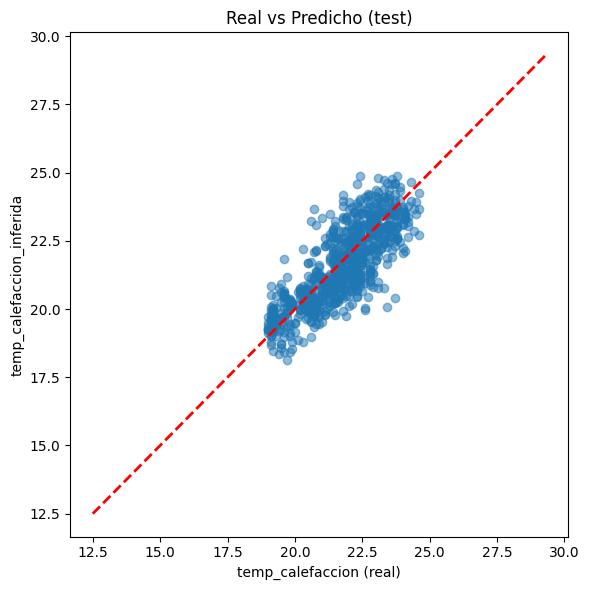

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_test, alpha=0.5)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax.set_xlabel('temp_calefaccion (real)')
ax.set_ylabel('temp_calefaccion_inferida')
ax.set_title('Real vs Predicho (test)')
plt.tight_layout()
plt.show()

In [4]:
df['temp_calefaccion_inferida'] = modelo.predict(X)
df[['temp_calefaccion', 'temp_calefaccion_inferida']].describe()

,temp_calefaccion,temp_calefaccion_inferida
count,3925.000000,3925.000000
mean,21.952025,21.928082
std,3.212218,3.117456
min,12.500000,12.382178
25%,20.500000,20.212176
50%,22.000000,21.974590
75%,24.200000,24.185063
max,29.300000,30.442141
